In [1]:
#Importing the needed modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
#Loading and reading the dataset
data = pd.read_csv("C:/Users/user/Desktop/Data analytics/diabetes_medication_clinical_trial1_3.csv")

In [3]:
data.head()

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
0,1,treatment,70,Female,10,8.7,8.7,0,NaN
1,2,placebo,46,Male,19,9.9,9.9,0,Fatigue
2,3,treatment,56,Male,17,8.6,8.6,0,NaN
3,4,treatment,59,Male,19,8.9,8.9,0,Headache
4,5,treatment,68,Male,5,9.1,9.1,0,NaN


In [4]:
data.tail()

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
1395,196,placebo,47,Female,15,7.2,6.50,24,NaN
1396,197,placebo,59,Female,16,8.6,7.88,24,NaN
1397,198,placebo,69,Female,11,8.2,7.48,24,NaN
1398,199,treatment,42,Male,5,9.9,7.50,24,NaN
1399,200,treatment,55,Female,4,7.3,4.90,24,Dizziness


## EXPLORATORY DATA ANALYSIS

In [5]:
#Viewing the number of rows and columns in the dataset
data.shape

(1400, 9)

In [6]:
#Exploring the information contained in the datset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   object 
 2   age                1400 non-null   int64  
 3   gender             1400 non-null   object 
 4   duration_diabetes  1400 non-null   int64  
 5   initial_hba1c      1400 non-null   float64
 6   hba1c              1400 non-null   float64
 7   time               1400 non-null   int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 98.6+ KB


In [7]:
#Checking for null values
data.isnull().sum()

subject_id              0
group                   0
age                     0
gender                  0
duration_diabetes       0
initial_hba1c           0
hba1c                   0
time                    0
adverse_event        1123
dtype: int64

In [8]:
# Deleting the rows with missing values
data = data.dropna()

In [9]:
# Checking to be certain there are no more missing values
data.isnull().sum()

subject_id           0
group                0
age                  0
gender               0
duration_diabetes    0
initial_hba1c        0
hba1c                0
time                 0
adverse_event        0
dtype: int64

In [10]:
#Converting date column to datetime format

data.loc[:, 'time'] = pd.to_datetime(data['time'])

In [11]:
# Determining the summary statistics of the dataset
data.describe()

,subject_id,age,duration_diabetes,initial_hba1c,hba1c,time
count,277.000000,277.000000,277.000000,277.000000,277.000000,277
mean,99.440433,55.018051,10.404332,8.527798,7.753718,1970-01-01 00:00:00.000000012
min,1.000000,40.000000,1.000000,7.000000,4.700000,1970-01-01 00:00:00
25%,50.000000,46.000000,5.000000,7.700000,6.980000,1970-01-01 00:00:00.000000004
50%,99.000000,56.000000,11.000000,8.500000,7.800000,1970-01-01 00:00:00.000000012
75%,151.000000,63.000000,16.000000,9.200000,8.500000,1970-01-01 00:00:00.000000020
max,200.000000,70.000000,20.000000,10.000000,10.000000,1970-01-01 00:00:00.000000024
std,57.984764,9.362837,5.800648,0.878272,1.114510,NaN


In [12]:
# Filter the DataFrame for the treatment group
treatment_group = data[data['group'] == 'treatment']
placebo_group = data[data['group'] == 'placebo']

# Calculate the average hemoglobin level for the treatment group
average_treatment_hba1c = treatment_group['hba1c'].mean()
average_placebo_hba1c = placebo_group['hba1c'].mean()

# Display the result
print(f"The average hemoglobin level for the treatment group is: {average_treatment_hba1c:.2f}")
print(f"The average hemoglobin level for the placebo group is: {average_placebo_hba1c:.2f}")

The average hemoglobin level for the treatment group is: 7.36
The average hemoglobin level for the placebo group is: 8.14


In [14]:
# Calculating the change in hemoglobin level for each subject

data['hba1c_change'] = data['hba1c'] - data['initial_hba1c']
data

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event,hba1c_change
1,2,placebo,46,Male,19,9.9,9.90,1970-01-01 00:00:00.000000000,Fatigue,0.00
3,4,treatment,59,Male,19,8.9,8.90,1970-01-01 00:00:00.000000000,Headache,0.00
6,7,treatment,69,Female,12,8.9,8.90,1970-01-01 00:00:00.000000000,Dizziness,0.00
7,8,treatment,44,Female,1,8.8,8.80,1970-01-01 00:00:00.000000000,Headache,0.00
10,11,treatment,52,Female,2,7.8,7.80,1970-01-01 00:00:00.000000000,Nausea,0.00
...,...,...,...,...,...,...,...,...,...,...
1376,177,treatment,48,Female,7,9.2,6.80,1970-01-01 00:00:00.000000024,Nausea,-2.40
1380,181,treatment,55,Male,18,8.1,5.70,1970-01-01 00:00:00.000000024,Fatigue,-2.40
1389,190,placebo,59,Female,1,7.7,6.98,1970-01-01 00:00:00.000000024,Nausea,-0.72
1394,195,treatment,45,Male,13,9.7,7.30,1970-01-01 00:00:00.000000024,Dizziness,-2.40


In [15]:
#Determining the occurrences of each adverse event

# Counting occurrences of each type of adverse event
adverse_event_counts = data['adverse_event'].value_counts()

# Displaying the result
adverse_event_counts

adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64

### DATA VISUALIZATION

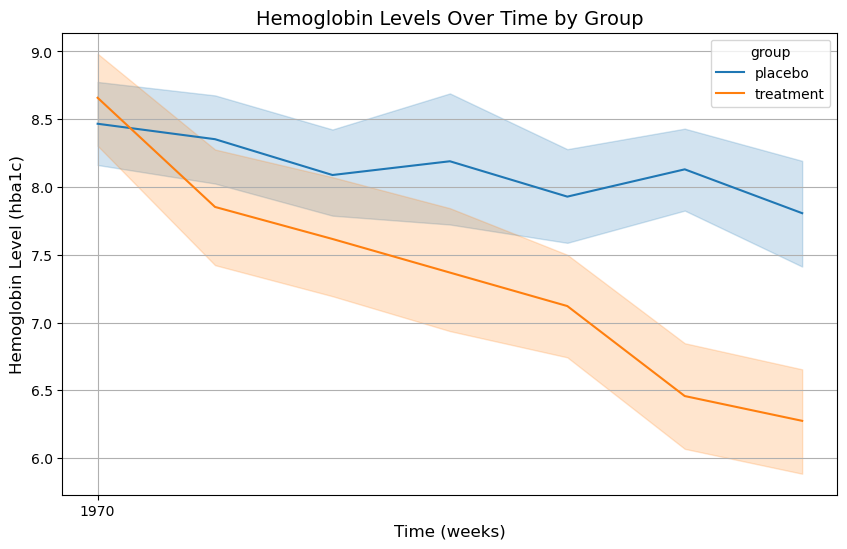

In [20]:
# Plotting hemoglobin levels over time for the Treatment groups.

plt.figure(figsize=(10, 6))

# Create a seaborn line plot for hemoglobin levels over time for both groups
sns.lineplot(data=data, x='time', y='hba1c', hue='group')

# Adding labels and title
plt.title('Hemoglobin Levels Over Time by Group', fontsize=14)
plt.xlabel('Time (weeks)', fontsize=12)
plt.ylabel('Hemoglobin Level (hba1c)', fontsize=12)
plt.grid(True)

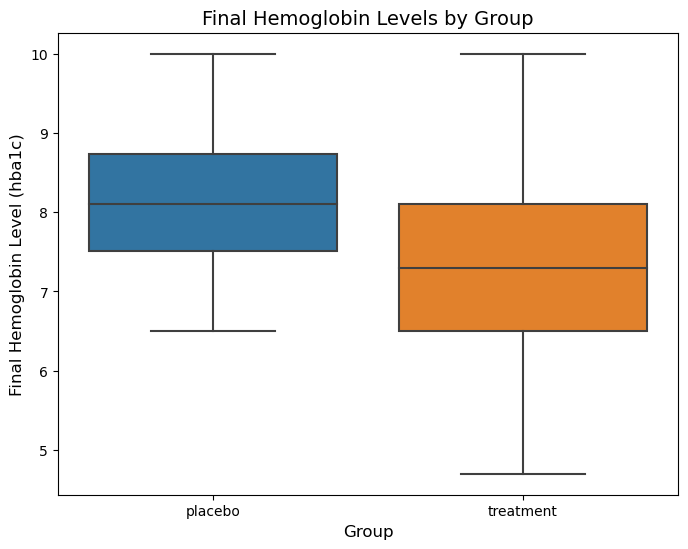

In [21]:
# Visualizing the final hemoglobin levels (hba1c) for both the treatment and placebo groups

# Setting plot size
plt.figure(figsize=(8, 6))

# Creating a seaborn boxplot to compare final hemoglobin levels across groups
sns.boxplot(data=data, x='group', y='hba1c')

# Adding labels and title
plt.title('Final Hemoglobin Levels by Group', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Final Hemoglobin Level (hba1c)', fontsize=12)

# Showing the plot
plt.show()

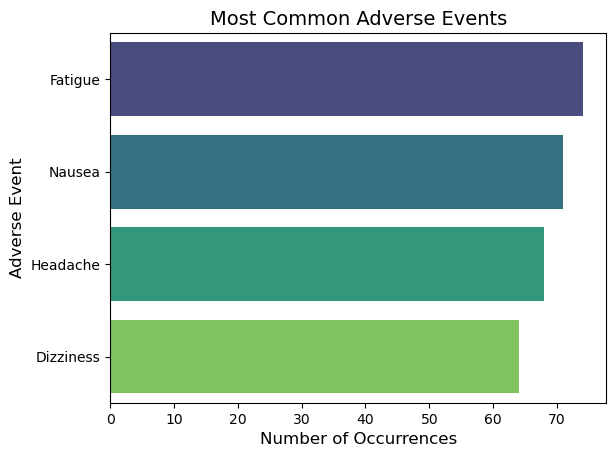

In [22]:
# Create a seaborn bar plot to show the most common adverse events

sns.barplot(x=adverse_event_counts.values, y=adverse_event_counts.index, palette='viridis')

# Adding labels and title
plt.title('Most Common Adverse Events', fontsize=14)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Adverse Event', fontsize=12)

# Showing the plot
plt.show()

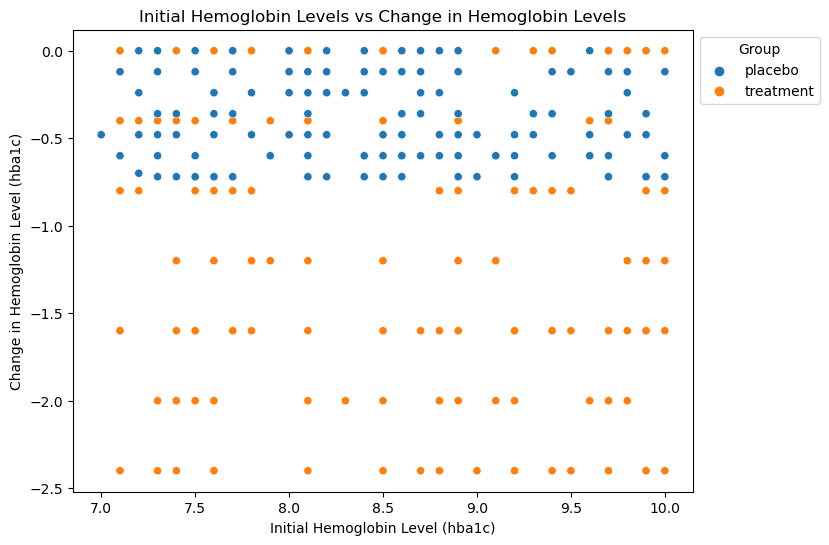

In [37]:
# Create a scatter plot comparing initial and change in hemoglobin levels

# Set plot size
plt.figure(figsize=(8, 6))

sns.scatterplot(data=data, x='initial_hba1c', y='hba1c_change', hue='group')

# Adding labels and title
plt.title('Initial Hemoglobin Levels vs Change in Hemoglobin Levels')
plt.xlabel('Initial Hemoglobin Level (hba1c)')
plt.ylabel('Change in Hemoglobin Level (hba1c)')

# Move the legend outside of the plot area
plt.legend(title='Group', loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
#plt.grid(True)
plt.show()

In [45]:
#Determining the level of significance of the change in haemoglobin levels among the groups

#Importing neccessary Library
from scipy import stats

# Split data into treatment and placebo groups
treatment_group = data[data['group'] == 'treatment']['hba1c_change']
placebo_group = data[data['group'] == 'placebo']['hba1c_change']

# Perform an independent t-test between the two groups
t_statistic, p_value = stats.ttest_ind(treatment_group, placebo_group)

# Output the results of the t-test
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')

T-statistic: -11.27003182492005
P-value: 1.7942513640603456e-24


In [47]:
# Perform one-way ANOVA on the dataset
model = ols('hba1c_change ~ C(group)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Output the ANOVA table
print(anova_table)

NameError: name 'ols' is not defined

In [13]:
#data = pd.get_dummies(data, columns=['group'], drop_first = True)
#data